In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
print(reg.score(X, y))
print(reg.coef_)
print(reg.intercept_)
print(reg.predict(np.array([[3, 5]])))

1.0
[1. 2.]
3.0000000000000018
[16.]


In [20]:
import numpy as np
import datasets

ds = datasets.load_dataset("scikit-learn/auto-mpg")
ds

DatasetDict({
    train: Dataset({
        features: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name'],
        num_rows: 398
    })
})

In [21]:
import pandas as pd

df = ds["train"].to_pandas()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB


In [22]:
df.drop(df[df.horsepower == "?"].index, inplace=True)
df = df.astype({'horsepower' : np.int64})
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
df = df.astype({'origin' : 'category'})
df.drop('car name', axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    int64   
 4   weight        392 non-null    int64   
 5   acceleration  392 non-null    float64 
 6   model year    392 non-null    int64   
 7   origin        392 non-null    category
dtypes: category(1), float64(3), int64(4)
memory usage: 24.9 KB


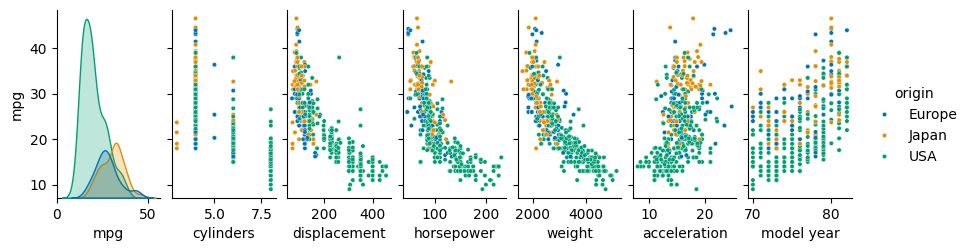

In [23]:
import seaborn as sns

sns.pairplot(
    df,
    y_vars="mpg",
    hue="origin",
    aspect=0.5,
    palette="colorblind",
    plot_kws=dict(marker="o", s=10),
)

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.concat([df, pd.get_dummies(df.origin, prefix="", prefix_sep="")], axis=1)
df.drop("origin", axis=1, inplace=True)
y = df.pop("mpg")
X = df
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

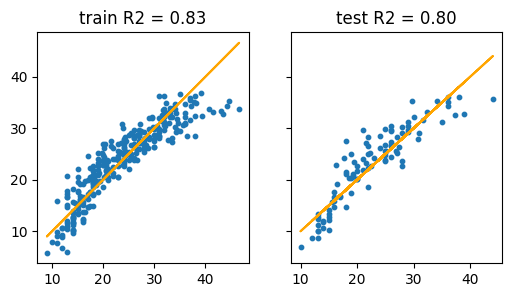

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey="all")
ax = axs[0]
ax.set_title(f"train R2 = {r2_train:.2f}")
ax.scatter(y_train, y_train_pred, s=10)
ax.plot(y_train, y_train, color="orange")
ax = axs[1]
ax.set_title(f"test R2 = {r2_test:.2f}")
ax.scatter(y_test, y_test_pred, s=10)
ax.plot(y_test, y_test, color="orange")

In [27]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

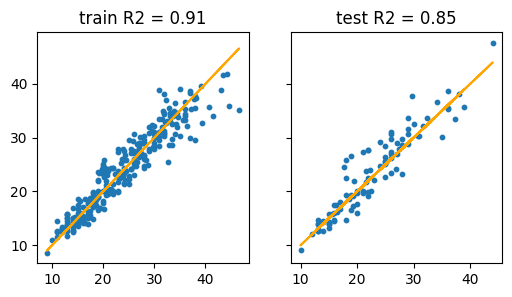

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey="all")
ax = axs[0]
ax.set_title(f"train R2 = {r2_train:.2f}")
ax.scatter(y_train, y_train_pred, s=10)
ax.plot(y_train, y_train, color="orange")
ax = axs[1]
ax.set_title(f"test R2 = {r2_test:.2f}")
ax.scatter(y_test, y_test_pred, s=10)
ax.plot(y_test, y_test, color="orange")